# Model Bayesian Poisson untuk Gol Piala Dunia

## Tujuan Analisis

Notebook ini berisi analisis jumlah gol per pertandingan Piala Dunia dengan model Bayesian Poisson. Data yang digunakan adalah Piala Dunia 2014, 2018, dan 2022.

Tujuan analisis adalah menghitung posterior untuk rata-rata gol per pertandingan, mengecek goodness-of-fit secara deskriptif, lalu membuat distribusi prediktif posterior untuk satu pertandingan Piala Dunia 2026. Notebook ini ditulis dalam Bahasa Indonesia sebagai pendamping presentasi.


## Model Statistik

Misalkan `Y_i` adalah total gol pada pertandingan ke-`i`. Karena gol adalah data hitungan, model awal yang digunakan adalah:

$$Y_i \mid \lambda \sim Poisson(\lambda)$$

Parameter `lambda` menyatakan rata-rata gol per pertandingan. Prior yang digunakan adalah:

$$\lambda \sim Gamma(1, 1)$$

Parameter Gamma ditulis dengan bentuk `shape-rate`. Jika data memiliki total gol $\sum y_i$ dan jumlah pertandingan $n$, maka posteriornya adalah:

$$\lambda \mid data \sim Gamma(1 + \sum y_i, 1 + n)$$


In [6]:
from pathlib import Path
import json
import math
import os

ROOT = Path.cwd()
while not (ROOT / "worldcup.json").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

MPLCONFIGDIR = ROOT / ".matplotlib_cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

DATA_DIR = ROOT / "worldcup.json"
ASSET_DIR = ROOT / "slides" / "assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_DIR.exists():
    raise FileNotFoundError("Folder worldcup.json tidak ditemukan dari lokasi kerja notebook.")


CHART_DPI = 160
COLOR_TEXT = "#111827"
COLOR_MUTED = "#374151"
COLOR_GRID = "#e5e7eb"
COLOR_BLUE = "#2563eb"
COLOR_LIGHT_BLUE = "#93c5fd"
COLOR_GREEN = "#059669"
COLOR_RED = "#dc2626"
COLOR_DARK = "#111827"
COLOR_ORANGE = "#f59e0b"


def style_axes(ax):
    ax.grid(axis="y", color=COLOR_GRID, linewidth=1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=11)


def save_figure(fig, filename):
    fig.tight_layout(rect=[0, 0.08, 1, 0.95])
    fig.savefig(ASSET_DIR / filename, dpi=CHART_DPI, bbox_inches="tight")


def load_worldcup_matches(year):
    path = DATA_DIR / str(year) / "worldcup.json"
    with path.open(encoding="utf-8") as file:
        data = json.load(file)
    return data["matches"]


def scored_matches(year):
    return [
        match for match in load_worldcup_matches(year)
        if "score" in match and ("ft" in match["score"] or "et" in match["score"])
    ]


def score_for_model(match):
    """Gunakan skor akhir termasuk extra time jika tersedia.

    Ini menjaga angka agregat tugas: 2014=171, 2018=169, 2022=172.
    Adu penalti tidak dihitung karena bukan gol dalam permainan.
    """
    score = match["score"]
    if "et" in score:
        return score["et"]
    return score["ft"]


def total_goals_by_match(year):
    return [sum(score_for_model(match)) for match in scored_matches(year)]


def frequency_table(values):
    counts = {}
    for value in values:
        counts[value] = counts.get(value, 0) + 1
    return dict(sorted(counts.items()))


def ascii_bar_chart(rows, label_key, value_key, width=32):
    max_value = max(row[value_key] for row in rows) if rows else 0
    for row in rows:
        value = row[value_key]
        bar_length = round((value / max_value) * width) if max_value else 0
        bar = "#" * bar_length
        print(f"{row[label_key]!s:>10} | {bar:<{width}} {value:.3f}")


def gamma_pdf(x, alpha, beta):
    log_density = alpha * math.log(beta) - math.lgamma(alpha) + (alpha - 1) * math.log(x) - beta * x
    return math.exp(log_density)


def poisson_pmf(k, lam):
    return math.exp(-lam + k * math.log(lam) - math.lgamma(k + 1))


def negative_binomial_predictive_pmf(k, alpha, beta):
    """Prediktif posterior P(Y_new = k) untuk model Gamma-Poisson."""
    log_coef = math.lgamma(k + alpha) - math.lgamma(alpha) - math.lgamma(k + 1)
    log_prob = log_coef + alpha * math.log(beta / (beta + 1)) + k * math.log(1 / (beta + 1))
    return math.exp(log_prob)


def credible_interval_from_pmf(rows, mass=0.90):
    lower_tail = (1 - mass) / 2
    upper_tail = 1 - lower_tail
    cumulative = 0.0
    lower = None
    upper = None
    for row in rows:
        cumulative += row["probability"]
        if lower is None and cumulative >= lower_tail:
            lower = row["goals"]
        if upper is None and cumulative >= upper_tail:
            upper = row["goals"]
            break
    return lower, upper

## Data: Piala Dunia 2014, 2018, dan 2022

Data diambil dari tiga edisi terakhir yang sudah selesai: 2014, 2018, dan 2022. Setiap observasi adalah total gol dalam satu pertandingan.

Aturan perhitungan skor:

- jika pertandingan memiliki skor extra time, skor `et` dipakai;
- jika tidak, skor `ft` dipakai;
- adu penalti tidak dihitung karena bukan gol dalam permainan.

Dengan aturan ini, total gol per edisi adalah 171, 169, dan 172 gol.


2014: 64 pertandingan, 171 gol, rata-rata = 2.672
2018: 64 pertandingan, 169 gol, rata-rata = 2.641
2022: 64 pertandingan, 172 gol, rata-rata = 2.688

Rata-rata gol per edisi:
      2014 | ################################ 2.672
      2018 | ###############################  2.641
      2022 | ################################ 2.688


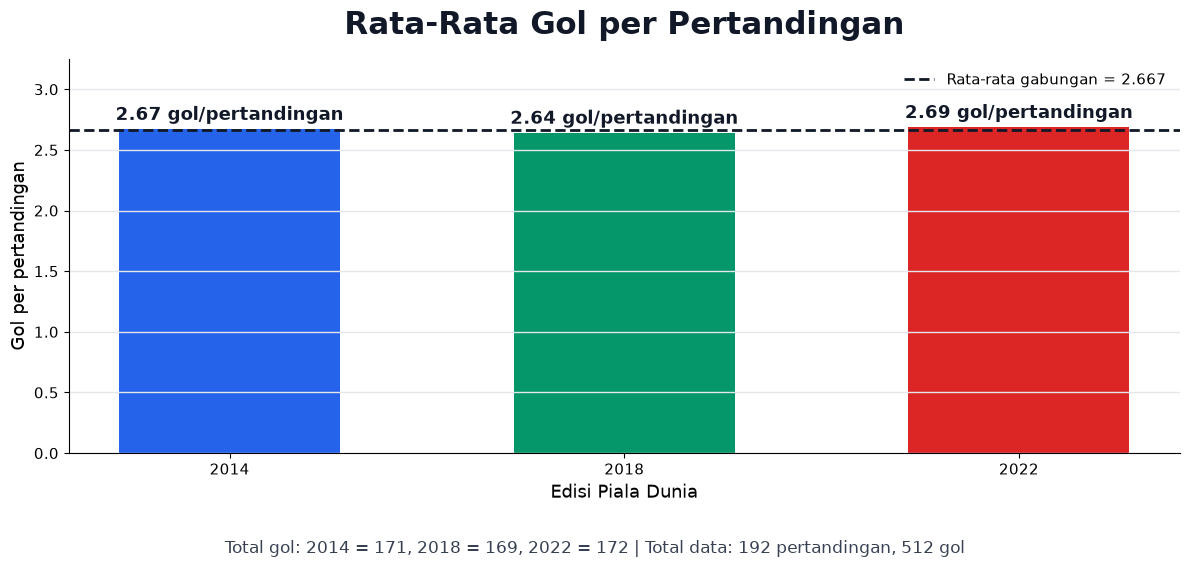

In [7]:
analysis_years = [2014, 2018, 2022]

summary_rows = []
train_goals = []
for year in analysis_years:
    goals = total_goals_by_match(year)
    train_goals.extend(goals)
    summary_rows.append({
        "year": year,
        "matches": len(goals),
        "total_goals": sum(goals),
        "avg_goals": sum(goals) / len(goals),
    })

for row in summary_rows:
    print(
        f"{row['year']}: {row['matches']} pertandingan, "
        f"{row['total_goals']} gol, rata-rata = {row['avg_goals']:.3f}"
    )

print("\nRata-rata gol per edisi:")
ascii_bar_chart(summary_rows, "year", "avg_goals")

try:
    import matplotlib.pyplot as plt

    combined_mean = sum(train_goals) / len(train_goals)
    years = [str(row["year"]) for row in summary_rows]
    averages = [row["avg_goals"] for row in summary_rows]
    total_goals = ", ".join(f"{row['year']} = {row['total_goals']}" for row in summary_rows)

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(years, averages, color=[COLOR_BLUE, COLOR_GREEN, COLOR_RED], width=0.56)
    ax.axhline(combined_mean, color=COLOR_DARK, linestyle="--", linewidth=2,
               label=f"Rata-rata gabungan = {combined_mean:.3f}")

    for bar, average in zip(bars, averages):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.04,
            f"{average:.2f} gol/pertandingan",
            ha="center",
            va="bottom",
            fontsize=13,
            fontweight="bold",
            color=COLOR_TEXT,
        )

    ax.set_title("Rata-Rata Gol per Pertandingan", fontsize=22, fontweight="bold", color=COLOR_TEXT, pad=18)
    ax.set_xlabel("Edisi Piala Dunia", fontsize=13)
    ax.set_ylabel("Gol per pertandingan", fontsize=13)
    ax.set_ylim(0, 3.25)
    ax.legend(frameon=False, loc="upper right", fontsize=11)
    style_axes(ax)
    fig.text(
        0.5,
        0.02,
        f"Total gol: {total_goals} | Total data: {len(train_goals)} pertandingan, {sum(train_goals)} gol",
        ha="center",
        fontsize=12,
        color=COLOR_MUTED,
    )
    save_figure(fig, "goals_by_edition.png")
    plt.show(block=False)
    plt.close(fig)
except ImportError:
    print("matplotlib tidak tersedia; grafik teks ditampilkan sebagai pengganti.")

## Hasil Posterior Gamma-Poisson

Prior utama adalah:

$$\lambda \sim Gamma(1,1)$$

Data memiliki 192 pertandingan dan 512 total gol, sehingga:

$$\lambda \mid data \sim Gamma(513,193)$$

Posterior mean mendekati rata-rata empiris, tetapi hasil Bayesian tetap menyimpan ketidakpastian parameter dalam bentuk distribusi.


Total pertandingan: 192
Total gol: 512
Rata-rata empiris: 2.667
Prior: Gamma(1, 1)
Posterior: Gamma(513, 193)
Posterior mean: 2.658
Posterior variance: 0.0138
Posterior standard deviation: 0.117
Aproksimasi 95% credible interval: [2.43, 2.89] gol


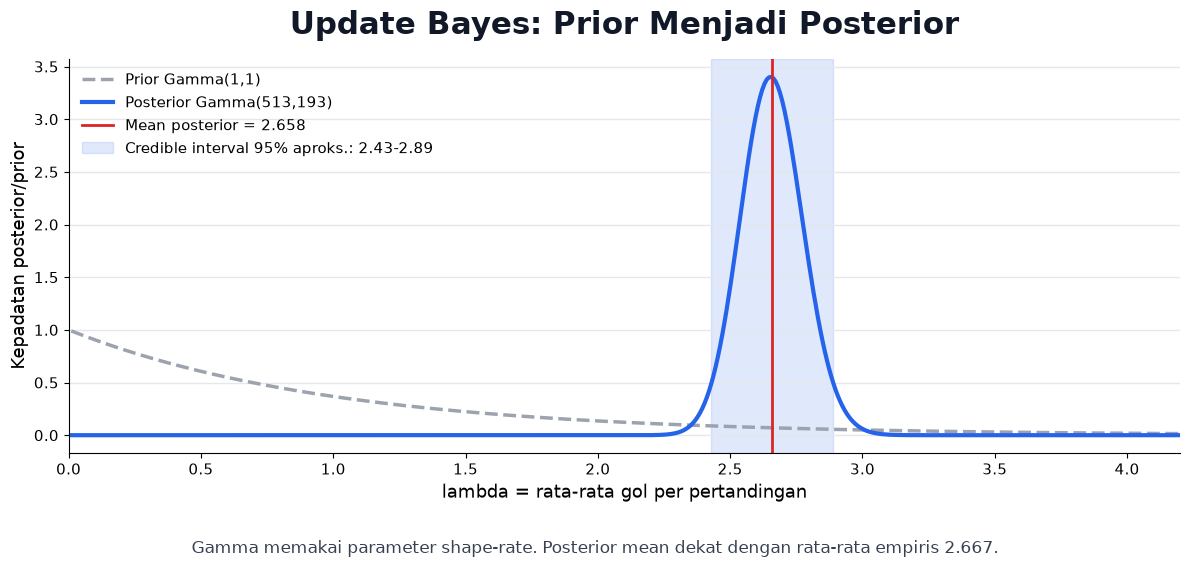

In [8]:
alpha_prior = 1.0
beta_prior = 1.0

train_total_goals = sum(train_goals)
train_match_count = len(train_goals)

alpha_post = alpha_prior + train_total_goals
beta_post = beta_prior + train_match_count

empirical_mean = train_total_goals / train_match_count
prior_mean = alpha_prior / beta_prior
posterior_mean = alpha_post / beta_post
posterior_variance = alpha_post / (beta_post ** 2)
posterior_sd = math.sqrt(posterior_variance)
normal_ci_95 = (posterior_mean - 1.96 * posterior_sd, posterior_mean + 1.96 * posterior_sd)

print(f"Total pertandingan: {train_match_count}")
print(f"Total gol: {train_total_goals}")
print(f"Rata-rata empiris: {empirical_mean:.3f}")
print(f"Prior: Gamma({alpha_prior:.0f}, {beta_prior:.0f})")
print(f"Posterior: Gamma({alpha_post:.0f}, {beta_post:.0f})")
print(f"Posterior mean: {posterior_mean:.3f}")
print(f"Posterior variance: {posterior_variance:.4f}")
print(f"Posterior standard deviation: {posterior_sd:.3f}")
print(f"Aproksimasi 95% credible interval: [{normal_ci_95[0]:.2f}, {normal_ci_95[1]:.2f}] gol")

try:
    import matplotlib.pyplot as plt
    import numpy as np

    xs = np.linspace(0.01, 4.2, 500)
    prior_density = [gamma_pdf(float(x), alpha_prior, beta_prior) for x in xs]
    posterior_density = [gamma_pdf(float(x), alpha_post, beta_post) for x in xs]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(xs, prior_density, label="Prior Gamma(1,1)", color="#9ca3af", linestyle="--", linewidth=2.5)
    ax.plot(xs, posterior_density, label="Posterior Gamma(513,193)", color=COLOR_BLUE, linewidth=3)
    ax.axvline(posterior_mean, label=f"Mean posterior = {posterior_mean:.3f}", color=COLOR_RED, linewidth=2)
    ax.axvspan(
        normal_ci_95[0],
        normal_ci_95[1],
        color=COLOR_BLUE,
        alpha=0.14,
        label=f"Credible interval 95% aproks.: {normal_ci_95[0]:.2f}-{normal_ci_95[1]:.2f}",
    )

    ax.set_title("Update Bayes: Prior Menjadi Posterior", fontsize=22, fontweight="bold", color=COLOR_TEXT, pad=18)
    ax.set_xlabel("lambda = rata-rata gol per pertandingan", fontsize=13)
    ax.set_ylabel("Kepadatan posterior/prior", fontsize=13)
    ax.set_xlim(0, 4.2)
    ax.legend(frameon=False, loc="upper left", fontsize=11)
    style_axes(ax)
    fig.text(
        0.5,
        0.02,
        f"Gamma memakai parameter shape-rate. Posterior mean dekat dengan rata-rata empiris {empirical_mean:.3f}.",
        ha="center",
        fontsize=12,
        color=COLOR_MUTED,
    )
    save_figure(fig, "prior_posterior_gamma.png")
    plt.show(block=False)
    plt.close(fig)
except ImportError:
    print("matplotlib/numpy tidak tersedia; ringkasan posterior ditampilkan di atas.")

## Goodness-of-Fit Deskriptif

Bagian ini membandingkan frekuensi aktual total gol dengan frekuensi yang diharapkan oleh distribusi Poisson menggunakan posterior mean.

Ukuran yang ditampilkan adalah statistik chi-square deskriptif. Interpretasinya dibatasi sebagai pemeriksaan awal: model dianggap cukup wajar jika pola aktual dan expected masih dekat, tetapi ini bukan validasi final bahwa model pasti benar.


gol | aktual | expected Poisson | kontribusi chi-square
  0 |     15 |            13.46 | 0.177
  1 |     37 |            35.77 | 0.042
  2 |     42 |            47.54 | 0.645
  3 |     53 |            42.12 | 2.812
  4 |     18 |            27.99 | 3.564
  5 |     12 |            14.88 | 0.557
  6 |      7 |             6.59 | 0.025
  7 |      6 |             2.50 | 4.887
  8 |      2 |             0.83 | 1.642
 9+ |      0 |             0.33 | 0.331

Statistik chi-square deskriptif: 14.682


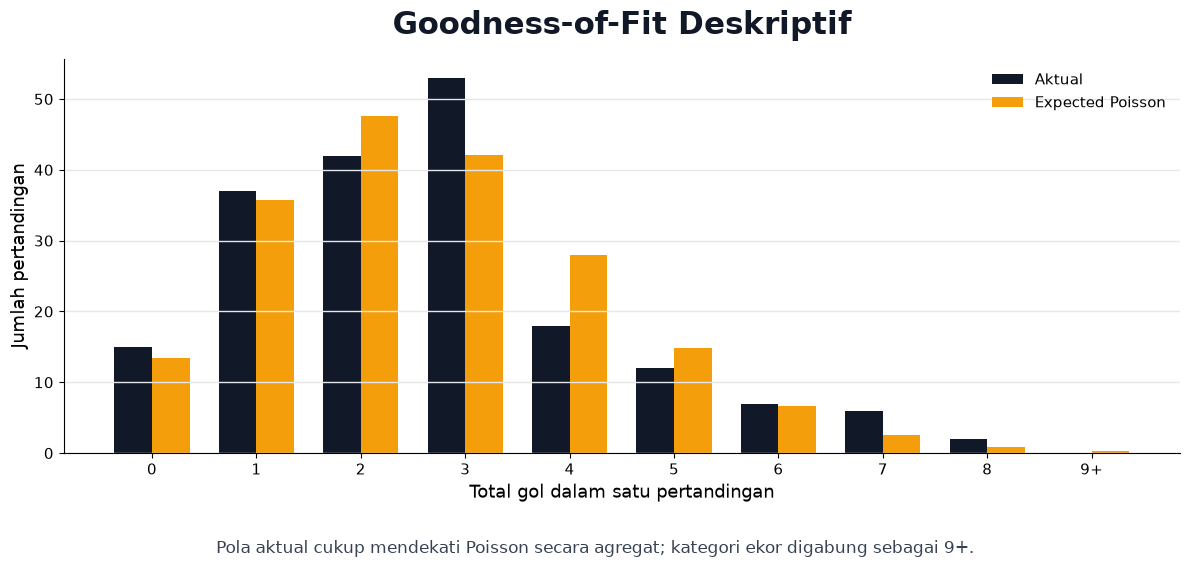

In [9]:
observed_frequency = frequency_table(train_goals)
observed_grouped = []
for k in range(0, 9):
    observed_grouped.append(observed_frequency.get(k, 0))
observed_grouped.append(sum(count for goal, count in observed_frequency.items() if goal >= 9))

expected_grouped = []
for k in range(0, 9):
    expected_grouped.append(train_match_count * poisson_pmf(k, posterior_mean))
expected_grouped.append(train_match_count * (1 - sum(poisson_pmf(k, posterior_mean) for k in range(0, 9))))

labels = [str(k) for k in range(0, 9)] + ["9+"]
goodness_of_fit_rows = []
chi_square_stat = 0.0
for label, observed, expected in zip(labels, observed_grouped, expected_grouped):
    contribution = ((observed - expected) ** 2 / expected) if expected > 0 else 0.0
    chi_square_stat += contribution
    goodness_of_fit_rows.append({
        "goals": label,
        "observed": observed,
        "expected": expected,
        "chi_square": contribution,
    })

print("gol | aktual | expected Poisson | kontribusi chi-square")
for row in goodness_of_fit_rows:
    print(f"{row['goals']:>3} | {row['observed']:>6} | {row['expected']:>16.2f} | {row['chi_square']:.3f}")
print(f"\nStatistik chi-square deskriptif: {chi_square_stat:.3f}")

try:
    import matplotlib.pyplot as plt

    x = list(range(len(labels)))
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar([v - 0.18 for v in x], observed_grouped, width=0.36, label="Aktual", color=COLOR_DARK)
    ax.bar([v + 0.18 for v in x], expected_grouped, width=0.36, label="Expected Poisson", color=COLOR_ORANGE)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title("Goodness-of-Fit Deskriptif", fontsize=22, fontweight="bold", color=COLOR_TEXT, pad=18)
    ax.set_xlabel("Total gol dalam satu pertandingan", fontsize=13)
    ax.set_ylabel("Jumlah pertandingan", fontsize=13)
    ax.legend(frameon=False, loc="upper right", fontsize=11)
    style_axes(ax)
    fig.text(
        0.5,
        0.02,
        "Pola aktual cukup mendekati Poisson secara agregat; kategori ekor digabung sebagai 9+.",
        ha="center",
        fontsize=12,
        color=COLOR_MUTED,
    )
    save_figure(fig, "goal_frequency_fit.png")
    plt.show(block=False)
    plt.close(fig)
except ImportError:
    print("matplotlib tidak tersedia; tabel goodness-of-fit ditampilkan di atas.")

## Distribusi Prediktif Posterior untuk 2026

Posterior `Gamma(513,193)` digunakan untuk memprediksi total gol pada satu pertandingan baru.

Untuk model Gamma-Poisson, prediktif posterior berbentuk Negative Binomial. Hasilnya berupa peluang untuk 0 gol, 1 gol, 2 gol, dan seterusnya, bukan satu angka tunggal. Bagian ini menjadi dasar prediksi posterior untuk 2026.


gol | probabilitas prediksi
  0 | 0.0706
  1 | 0.1866
  2 | 0.2472
  3 | 0.2187
  4 | 0.1455
  5 | 0.0775
  6 | 0.0345
  7 | 0.0132
  8 | 0.0044
  9 | 0.0013
10+ | 0.0005

Interval prediktif posterior 90% untuk satu pertandingan 2026: 0 sampai 6 gol
P(0-1 gol): 0.257
P(2-3 gol): 0.466
P(4+ gol): 0.277


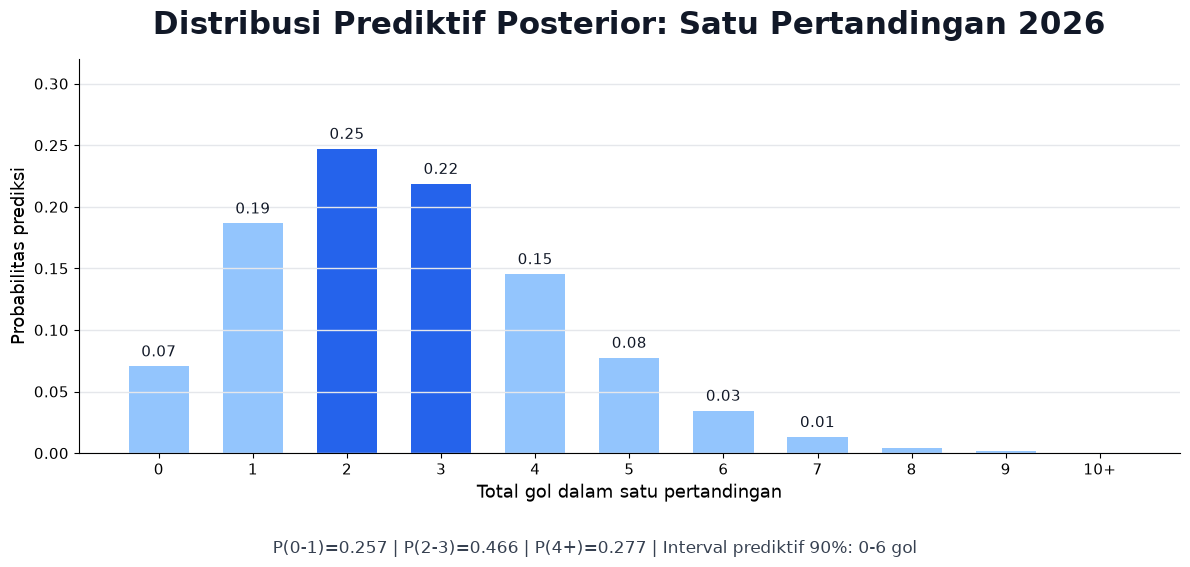

In [10]:
predictive_rows = []
for k in range(0, 10):
    predictive_rows.append({
        "goals": k,
        "probability": negative_binomial_predictive_pmf(k, alpha_post, beta_post),
    })
prob_10_plus = 1 - sum(row["probability"] for row in predictive_rows)
interval_90 = credible_interval_from_pmf(predictive_rows + [{"goals": 10, "probability": prob_10_plus}], mass=0.90)

print("gol | probabilitas prediksi")
for row in predictive_rows:
    print(f"{row['goals']:>3} | {row['probability']:.4f}")
print(f"10+ | {prob_10_plus:.4f}")
print(f"\nInterval prediktif posterior 90% untuk satu pertandingan 2026: {interval_90[0]} sampai {interval_90[1]} gol")

prob_0_to_1 = sum(row["probability"] for row in predictive_rows if row["goals"] <= 1)
prob_2_to_3 = sum(row["probability"] for row in predictive_rows if row["goals"] in [2, 3])
prob_4_plus = 1 - sum(row["probability"] for row in predictive_rows if row["goals"] <= 3)
print(f"P(0-1 gol): {prob_0_to_1:.3f}")
print(f"P(2-3 gol): {prob_2_to_3:.3f}")
print(f"P(4+ gol): {prob_4_plus:.3f}")

try:
    import matplotlib.pyplot as plt

    labels_plot = [str(row["goals"]) for row in predictive_rows] + ["10+"]
    probs_plot = [row["probability"] for row in predictive_rows] + [prob_10_plus]
    colors = [COLOR_BLUE if label in ["2", "3"] else COLOR_LIGHT_BLUE for label in labels_plot]

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(labels_plot, probs_plot, color=colors, width=0.64)
    for label, bar, probability in zip(labels_plot, bars, probs_plot):
        if probability >= 0.01:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{probability:.2f}",
                ha="center",
                va="bottom",
                fontsize=11,
                color=COLOR_TEXT,
            )

    ax.set_title("Distribusi Prediktif Posterior: Satu Pertandingan 2026", fontsize=22, fontweight="bold", color=COLOR_TEXT, pad=18)
    ax.set_xlabel("Total gol dalam satu pertandingan", fontsize=13)
    ax.set_ylabel("Probabilitas prediksi", fontsize=13)
    ax.set_ylim(0, 0.32)
    style_axes(ax)
    fig.text(
        0.5,
        0.02,
        f"P(0-1)={prob_0_to_1:.3f} | P(2-3)={prob_2_to_3:.3f} | P(4+)={prob_4_plus:.3f} | Interval prediktif 90%: {interval_90[0]}-{interval_90[1]} gol",
        ha="center",
        fontsize=12,
        color=COLOR_MUTED,
    )
    save_figure(fig, "posterior_predictive_2026.png")
    plt.show(block=False)
    plt.close(fig)
except ImportError:
    print("matplotlib tidak tersedia; probabilitas prediksi ditampilkan di atas.")

## Kesimpulan dan Keterbatasan

Kesimpulan utama:

- data 2014, 2018, dan 2022 berisi 192 pertandingan dan 512 gol;
- posterior model adalah `Gamma(513,193)`;
- posterior mean adalah sekitar 2.658 gol per pertandingan;
- prediktif posterior menunjukkan pertandingan dengan 2 sampai 3 gol sebagai kelompok paling mungkin;
- interval prediktif 90% untuk satu pertandingan 2026 adalah 0 sampai 6 gol.

Keterbatasan model:

- semua pertandingan memakai satu rata-rata gol yang sama;
- kekuatan tim belum dimodelkan;
- fase grup dan fase gugur belum dibedakan;
- skor rendah seperti 0-0 dan 1-1 dapat membutuhkan koreksi khusus seperti Dixon-Coles;
- model hierarkis berbasis kekuatan tim dapat menjadi pengembangan lanjutan.
